In [114]:
from utils import read_gbq
import matplotlib.pyplot as plt
from tableone import TableOne
from pathlib import Path
import seaborn as sns
import pandas as pd
import numpy as np
import os
from utils import read_gbq, rename_cols #,compute_effect_per_unit
import matplotlib.pyplot as plt
from tableone import TableOne
from collections import Counter
from pathlib import Path
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
import os
from tqdm import tqdm
from utils import treatment_effect
from scipy.stats import norm, zscore

from utils import read_gbq, rename_cols #,compute_effect_per_unit
import matplotlib.pyplot as plt
from tableone import TableOne
from collections import Counter
from pathlib import Path
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
import os
from tqdm import tqdm
from utils import treatment_effect,compute_unit, compute_effect_per_unit
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.base import clone
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import Pipeline
from scipy.stats import norm, zscore
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
import lightgbm as lgb
import shap
import statsmodels.api as sm

SEED = 42

warnings.filterwarnings("ignore")
plt.rcParams['axes.grid'] = True

In [89]:
df=pd.read_csv('df_official_april10.csv')

In [90]:
df = df[['patientunitstayid', 'baseline', 'post_treatment', 'treatment_effect',
       'treatment_value', 'treatment_offset', '_offset', '_window_size',
       'n_baseline', 'n_post_treatment', 'aggfunc', 'age', 'gender',
       'ethnicity', 'initial_weight', 'icu_outcome', 'hosp_outcome', 'units',
       'treatment_effect_per_unit', 'response']]
df.head()

,patientunitstayid,baseline,post_treatment,treatment_effect,treatment_value,treatment_offset,_offset,_window_size,n_baseline,n_post_treatment,aggfunc,age,gender,ethnicity,initial_weight,icu_outcome,hosp_outcome,units,treatment_effect_per_unit,response
0,141233,10.5,8.90,-1.60,199.0,5.083333,6,12,2,1,mean,81.0,Female,Caucasian,61.7,discharged,discharged,0.603030,-2.653266,non_responder
1,141304,6.9,8.30,1.40,320.0,33.883333,6,12,1,1,mean,70.0,Male,Caucasian,NaN,discharged,discharged,0.969697,1.443750,responder
2,141547,10.2,11.05,0.85,300.0,9.000000,6,12,1,2,mean,79.0,Female,Caucasian,52.6,discharged,discharged,0.909091,0.935000,non_responder
3,142483,6.5,7.20,0.70,300.0,215.283333,6,12,1,1,mean,68.0,Male,African American,54.7,discharged,discharged,0.909091,0.770000,non_responder
4,142623,7.2,10.30,3.10,331.0,84.900000,6,12,1,1,mean,47.0,Female,Asian,NaN,discharged,discharged,1.003030,3.090634,responder


In [91]:
# y = df['treatment_effect_per_unit']
# y=df['response'].apply(lambda x: 1 if x=='responder' else 0)
# df['categorical_gender']=df['gender'].apply(lambda x: 1 if x=='Male' else 0)
# Gender is 1 for male, 0 for female
censor =['patientunitstayid', 'post_treatment', 'treatment_effect','treatment_value', 
        '_offset', '_window_size', 'n_baseline', 'n_post_treatment', 'aggfunc',
        'icu_outcome', 'hosp_outcome', 'treatment_effect_per_unit', 'response'] # remove n_baseline

feat_keep = ~df.columns.isin(censor)
X = df.loc[:,feat_keep]

# X = X[[c for c in feat_keep if c in X.columns]].copy()

num_cols=X.select_dtypes(include=['float64','int64']).columns.tolist()
cat_cols=X.select_dtypes(include=['object']).columns.tolist()

num_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

cat_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown='ignore', drop='first'))
])

pre=ColumnTransformer([
    ('num',num_pipeline,num_cols),
    ('cat',cat_pipeline,cat_cols)
])

Preprocessing / Pipeline

In [92]:
# y = df['treatment_effect_per_unit']
y=df['response'].apply(lambda x: 1 if x=='responder' else 0)
# df['categorical_gender']=df['gender'].apply(lambda x: 1 if x=='Male' else 0)
# Gender is 1 for male, 0 for female
censor =['patientunitstayid', 'post_treatment', 'treatment_effect','treatment_value', 
        '_offset', '_window_size', 'n_baseline', 'n_post_treatment', 'aggfunc',
        'icu_outcome', 'hosp_outcome', 'treatment_effect_per_unit', 'response'] # remove n_baseline

feat_keep = ~df.columns.isin(censor)
X = df.loc[:,feat_keep]

# X = X[[c for c in feat_keep if c in X.columns]].copy()

num_cols=X.select_dtypes(include=['float64','int64']).columns.tolist()
cat_cols=X.select_dtypes(include=['object']).columns.tolist()

num_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

cat_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

pre=ColumnTransformer([
    ('num',num_pipeline,num_cols),
    ('cat',cat_pipeline,cat_cols)
])

### Statsmodel

In [93]:
print(df.shape)
print(df.patientunitstayid.nunique())

(8366, 20)
8366


In [94]:
pre_fitted = pre.fit(X, y)
X_tx = pre_fitted.transform(X)
feat_names = pre_fitted.get_feature_names_out()


In [95]:
import statsmodels.api as sm

pre_fitted = pre.fit(X, y)
X_tx = pre_fitted.transform(X)
feat_names = pre_fitted.get_feature_names_out()

# Add an intercept
X_const = sm.add_constant(X_tx, has_constant="add")

groups = df["patientunitstayid"] if "patientunitstayid" in df.columns else None
logit = sm.Logit(y, X_const)

if groups is not None:
    fit = logit.fit(disp=False, cov_type="cluster", cov_kwds={"groups": groups})
    # fit_reg = sm.Logit(y, Xd_const).fit_regularized(alpha=1e-4, L1_wt=0.0)  # small L2
else:
    fit = logit.fit(disp=False)

# -----------------------------------------------------------
# 4. Build table of ORs and 95 % CIs
# -----------------------------------------------------------
B   = fit.params                      # log-odds coefficients
SE  = fit.bse                         # standard errors
z   = B / SE
p   = fit.pvalues
CI  = fit.conf_int()                  # 95 % CI in log-odds scale

OR      = np.exp(B)
OR_low  = np.exp(CI[0])
OR_high = np.exp(CI[1])

or_table = pd.DataFrame({
    "B (log-odds)": B,
    "Std. error": SE,
    "z": z,
    "p": p,
    "OR": OR,
    "OR 95% CI low": OR_low,
    "OR 95% CI high": OR_high,
})

# Add clear feature names
if len(feat_names) + 1 == len(or_table):   # +1 for intercept
    or_table.index = ["(Intercept)"] + list(feat_names)


for i in or_table['p']:
    if i < 0.001:
        # print(i)
        or_table.loc[or_table['p']==i, 'p']='<0.001'


display(or_table.round(3))

,B (log-odds),Std. error,z,p,OR,OR 95% CI low,OR 95% CI high
(Intercept),0.572,0.081,7.051,<0.001,1.772,1.512,2.078
num__baseline,-1.101,0.036,-30.558,<0.001,0.333,0.310,0.357
num__treatment_offset,0.078,0.028,2.801,0.00509,1.082,1.024,1.143
num__age,0.133,0.027,4.971,<0.001,1.142,1.084,1.203
num__initial_weight,-0.308,0.027,-11.497,<0.001,0.735,0.697,0.774
num__units,-0.475,0.030,-16.045,<0.001,0.622,0.587,0.659
cat__gender_Male,-0.377,0.052,-7.305,<0.001,0.686,0.620,0.759
cat__ethnicity_Asian,0.420,0.232,1.807,0.070784,1.522,0.965,2.401
cat__ethnicity_Caucasian,-0.044,0.083,-0.533,0.593791,0.957,0.814,1.125
cat__ethnicity_Hispanic,-0.343,0.134,-2.550,0.010776,0.710,0.545,0.924


LOGREG MDOEL

In [102]:
# clf = Pipeline([
#     ('pre', pre),
#     ('clf', LogisticRegression(class_weight={0:0.42, 1:0.58}, max_iter=1000, random_state=SEED))
# ])

clf = Pipeline([
    ('pre', pre),
    ('clf', LogisticRegression(
        penalty="elasticnet", solver="saga",
        l1_ratio=0.5, C=0.5, max_iter=5000, class_weight="balanced", random_state=SEED, 
    ))
])

In [103]:
y=df['response'].apply(lambda x: 1 if x=='responder' else 0)

In [104]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

In [105]:
clf.fit(X_train, y_train)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['baseline',
                                                   'treatment_offset', 'age',
                                                   'initial_weight', 'units']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'ethnicity'])])),
                ('clf',
                 LogisticRegression(C=0.5, class_weight='balanced',
                                    l1_ratio=0.5, max_iter=5000,
                                    penalty='elasticnet', random_state=42,
                                    solver='saga'))])

In [106]:
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]  # for probability of “responsive”


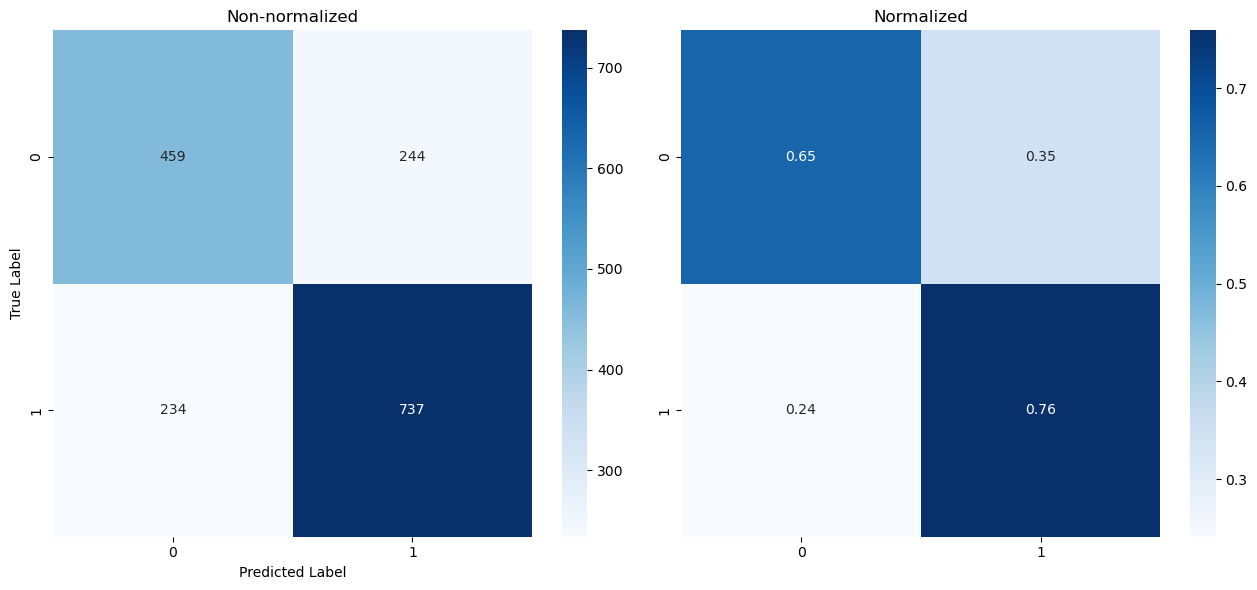

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(13,6))
plt.subplot(1,2,1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.grid(False)
plt.title('Non-normalized')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.subplot(1,2,2)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
sns.heatmap(cm_norm, annot=True, cmap='Blues')

plt.title('Normalized')
plt.grid(False)
plt.tight_layout()
plt.show()

In [109]:
# baseline log reg
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUROC:", roc_auc_score(y_test, y_proba))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.7144563918757467
AUROC: 0.7866931921894251
[[459 244]
 [234 737]]
              precision    recall  f1-score   support

           0       0.66      0.65      0.66       703
           1       0.75      0.76      0.76       971

    accuracy                           0.71      1674
   macro avg       0.71      0.71      0.71      1674
weighted avg       0.71      0.71      0.71      1674



Odds Ratios

In [110]:
feature_names = clf.named_steps['pre'].get_feature_names_out()
coefs = clf.named_steps['clf'].coef_[0]

importance = pd.DataFrame({'feature': feature_names, 'coef': coefs})
importance['odds_ratio'] = np.exp(importance['coef'])
importance.sort_values(by='odds_ratio', ascending=False)


,feature,coef,odds_ratio
6,cat__ethnicity_Asian,0.338292,1.402551
2,num__age,0.155675,1.168446
1,num__treatment_offset,0.086375,1.090215
9,cat__ethnicity_Native American,-0.087980,0.915779
7,cat__ethnicity_Caucasian,-0.096579,0.907938
10,cat__ethnicity_Other/Unknown,-0.106384,0.899080
3,num__initial_weight,-0.299413,0.741253
8,cat__ethnicity_Hispanic,-0.305621,0.736666
5,cat__gender_Male,-0.350951,0.704018
4,num__units,-0.472794,0.623258


ROC/AUC

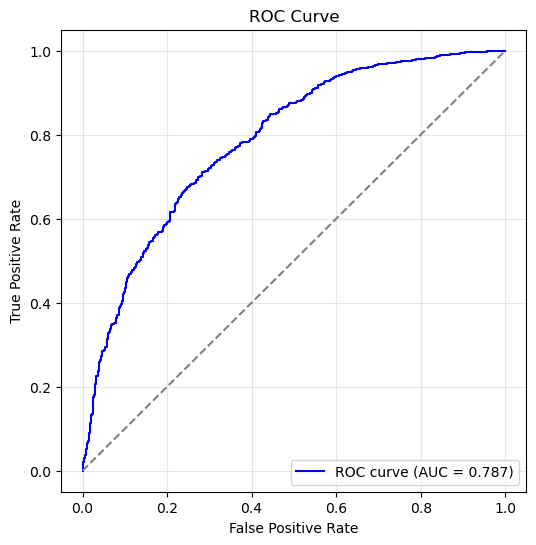

In [111]:
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]  # for probability of “responsive”

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

# Plot ROC
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

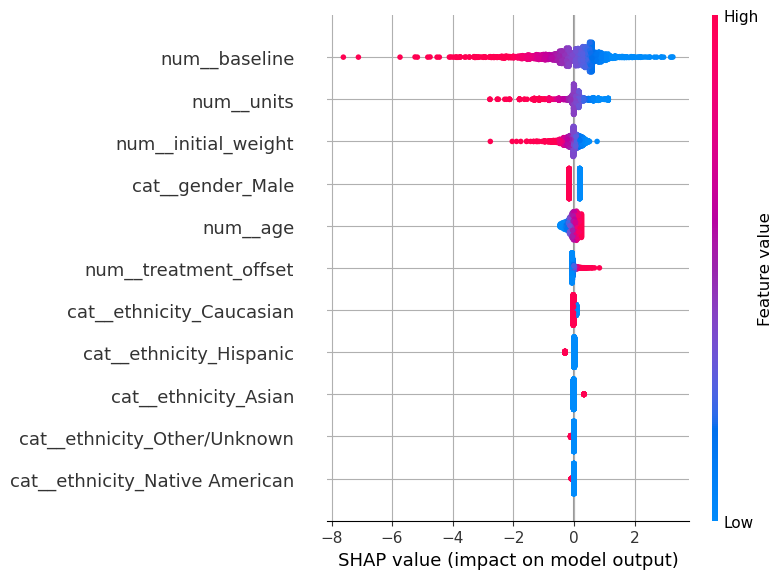

In [115]:
import shap
import numpy as np


X_test_pre=pre.fit_transform(X_test)
# Get feature names from preprocessor
feature_names = pre.get_feature_names_out()

X_train_transformed = pre.fit_transform(X_train)
explainer = shap.Explainer(clf.named_steps['clf'], X_train_transformed, feature_names=feature_names)
shap_values = explainer(X_test_pre)

# Visualize with feature names
shap.summary_plot(shap_values, X_test_pre, feature_names=feature_names)